<a href="https://colab.research.google.com/github/Musarrat1/Assembly/blob/main/tealeaf.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import tensorflow as tf

print("TF:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

gpus = tf.config.list_physical_devices("GPU")
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
print("✅ Memory growth set")

TF: 2.19.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
✅ Memory growth set


In [7]:
import os, glob, numpy as np
import tensorflow as tf
from tensorflow.keras import layers
import matplotlib.pyplot as plt

In [8]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [9]:
!ls /content/drive/MyDrive

 classification_report.txt
 Classroom
'Colab Notebooks'
'Cv (2) (1).pdf'
'Cv (2).pdf'
 CV.pdf
 gradcam_outputs
 IMG_3124.JPG
 IMG_3180.JPG
 IMG_3349.JPG
 IMG_3389.JPG
 IMG_3399.JPG
 IMG_3401.JPG
 IMG_3404.JPG
 IMG_3409.JPG
 IMG_3410.JPG
 IMG_3411.JPG
 IMG_3418.JPG
 IMG_3447.JPG
 IMG_3459.JPG
 IMG_3468.JPG
 IMG_3479.JPG
 IMG_3827.JPG
 IMG_3828.JPG
 IMG_3831.JPG
 IMG_3832.JPG
 IMG_3864.JPG
 IMG_3865.JPG
 IMG_4508.JPG
 IMG_4773.JPG
 IMG_4973.JPG
 IMG_5072.JPG
 IMG_5078.JPG
 IMG_5081.JPG
 IMG_5090.JPG
 IMG_5140.JPG
 IMG_5141.JPG
 IMG_5148.JPG
 IMG_5190.JPG
 IMG_5197.JPG
 IMG_5201.JPG
 IMG_5203.JPG
 IMG_5265.JPG
 IMG_5266.JPG
 IMG_5267.JPG
 IMG_5268.JPG
 IMG_5273.JPG
 IMG_5577.JPG
 IMG_5631.JPG
 IMG_5666.JPG
 IMG_5669.JPG
 IMG_5735.JPG
 IMG_5791.JPG
 IMG_5824.JPG
 IMG_5826.JPG
 IMG_5853.JPG
 IMG_5855.JPG
 IMG_5866.JPG
 IMG_6043.JPG
 IMG_6174.JPG
 IMG_6194.JPG
 IMG_6238.JPG
 IMG_6353.JPG
 IMG_6356.JPG
 IMG_6474.JPG
 IMG_6476.JPG
 IMG_6590.JPG
 IMG_6593.JPG
 IMG_7010.JPG
 IMG_7344.JPG
 IMG_73

In [10]:
!cp /content/drive/MyDrive/TeaDataset.zip /content/
!mkdir -p /content/dataset
!unzip -o /content/TeaDataset.zip -d /content/dataset

Streaming output truncated to the last 5000 lines.
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5917.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5918.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5919.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust592.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5920.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5921.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5922.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5923.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5924.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5925.jpg  
  inflating: /content/dataset/TeaDataset/TeaDataset/Red rust/Leaf_Red_Rust5926.jpg  
  inflating: /c

In [11]:
import os
import glob
DATA_DIR = "/content/dataset/TeaDataset/TeaDataset"
class_folders = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
counts = {}
for c in class_folders:
    counts[c] = len(glob.glob(os.path.join(DATA_DIR, c, "*.*")))

print("✅ Class counts:")
for k,v in counts.items():
    print(f"{k}: {v}")
print("Total images:", sum(counts.values()))

✅ Class counts:
7. Healthy leaf: 13764
Brown Blight: 14507
Grey Blight: 2024
Helopelties: 14289
Red rust: 14001
Total images: 58585


In [12]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers

IMG_SIZE = (224, 224)   # safest; later you can try 256 if stable
BATCH = 8             # if still crashes -> set 8
SEED = 123

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical"
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names
num_classes = len(class_names)
print("✅ TF class order:", class_names)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.shuffle(1000).prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

Found 58585 files belonging to 5 classes.
Using 46868 files for training.
Found 58585 files belonging to 5 classes.
Using 11717 files for validation.
✅ TF class order: ['7. Healthy leaf', 'Brown Blight', 'Grey Blight', 'Helopelties', 'Red rust']


In [13]:
import numpy as np
# counts must match TF class_names order
total = sum(counts.values())
K = len(class_names)

class_weights = {}
for i, name in enumerate(class_names):
    c = counts.get(name, None)
    if c is None or c == 0:
        class_weights[i] = 1.0
    else:
        class_weights[i] = total / (K * c)

# clip to avoid instability (important)
class_weights_clipped = {k: float(min(v, 1.8)) for k, v in class_weights.items()}

print("✅ Raw weights:", class_weights)
print("✅ Clipped weights:", class_weights_clipped)

✅ Raw weights: {0: 0.8512786980528916, 1: 0.807679051492383, 2: 5.789031620553359, 3: 0.8200013996780741, 4: 0.8368687950860653}
✅ Clipped weights: {0: 0.8512786980528916, 1: 0.807679051492383, 2: 1.8, 3: 0.8200013996780741, 4: 0.8368687950860653}


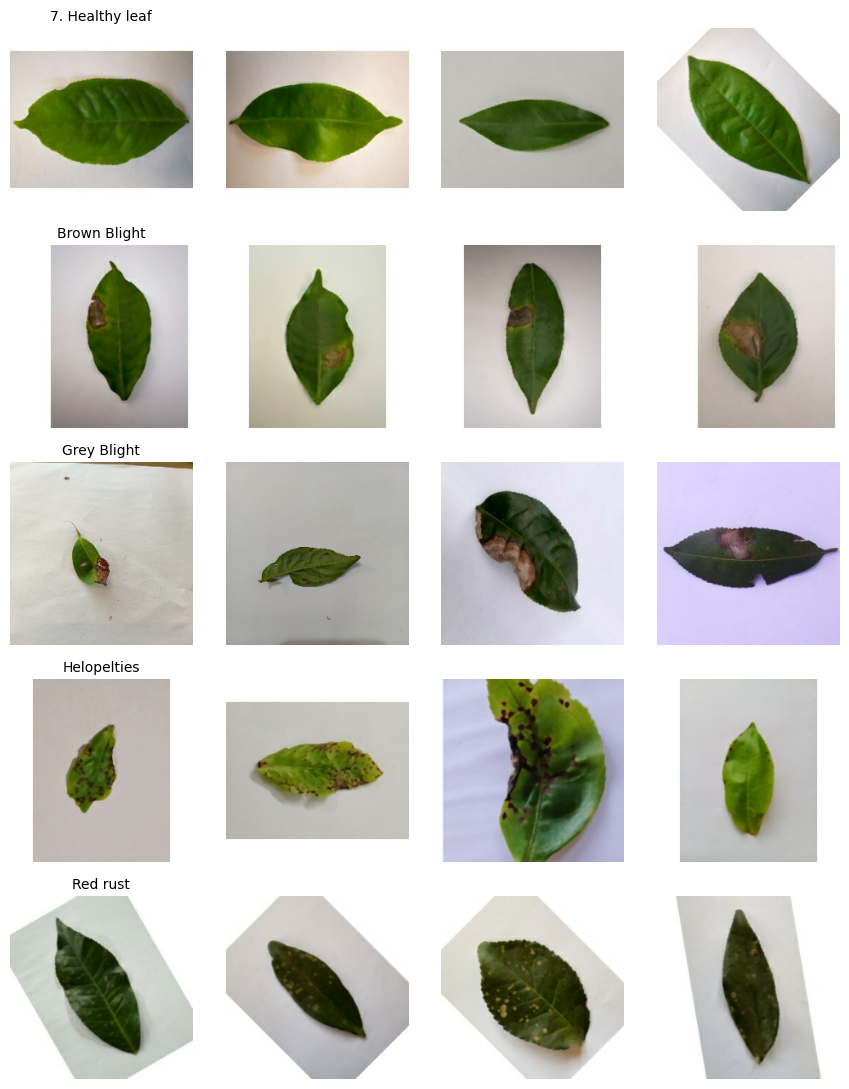

In [14]:
import matplotlib.pyplot as plt
import numpy as np

N_PER_CLASS = 4  # increase to 5 if you want
samples = {i: [] for i in range(num_classes)}

for images, labels in train_ds:
    y = np.argmax(labels.numpy(), axis=1)
    for i, cls in enumerate(y):
        if len(samples[cls]) < N_PER_CLASS:
            samples[cls].append(images[i].numpy().astype("uint8"))
    if all(len(samples[k]) >= N_PER_CLASS for k in samples):
        break

rows = num_classes
cols = N_PER_CLASS
plt.figure(figsize=(cols*2.2, rows*2.2))
idx = 1
for r in range(rows):
    for c in range(cols):
        plt.subplot(rows, cols, idx)
        plt.imshow(samples[r][c])
        plt.axis("off")
        if c == 0:
            plt.title(class_names[r], fontsize=10)
        idx += 1
plt.tight_layout()
plt.show()

In [15]:
aug = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.EfficientNetB0(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
x = aug(inputs)
x = tf.keras.applications.efficientnet.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.35)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = tf.keras.Model(inputs, outputs)
model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,055,976 (15.47 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 4,049,571 (15.45 MB)

In [16]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=4, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=2),
    tf.keras.callbacks.ModelCheckpoint("best_model.keras", monitor="val_accuracy", save_best_only=True),
]

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

USE_CLASS_WEIGHT = True  # set False if unstable or accuracy drops

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=12,
    class_weight=(class_weights_clipped if USE_CLASS_WEIGHT else None),
    callbacks=callbacks
)

Epoch 1/12
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 333s 52ms/step - accuracy: 0.9023 - loss: 0.2709 - val_accuracy: 0.9735 - val_loss: 0.0822 - learning_rate: 0.0010
Epoch 2/12
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 276s 44ms/step - accuracy: 0.9549 - loss: 0.1204 - val_accuracy: 0.9566 - val_loss: 0.1451 - learning_rate: 0.0010
Epoch 3/12
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 280s 45ms/step - accuracy: 0.9578 - loss: 0.1136 - val_accuracy: 0.9668 - val_loss: 0.1085 - learning_rate: 0.0010
Epoch 4/12
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 281s 45ms/step - accuracy: 0.9599 - loss: 0.1080 - val_accuracy: 0.9691 - val_loss: 0.0998 - learning_rate: 5.0000e-04
Epoch 5/12
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 324s 45ms/step - accuracy: 0.9613 - loss: 0.1056 - val_accuracy: 0.9663 - val_loss: 0.1126 - learning_rate: 5.0000e-04


In [17]:
base_model.trainable = True
for layer in base_model.layers[:-30]:  # safe; change to -20 if GPU strong
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=8,
    class_weight=(class_weights_clipped if USE_CLASS_WEIGHT else None),
    callbacks=callbacks
)

Epoch 1/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 360s 55ms/step - accuracy: 0.8995 - loss: 0.2532 - val_accuracy: 0.9759 - val_loss: 0.0775 - learning_rate: 1.0000e-05
Epoch 2/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 348s 56ms/step - accuracy: 0.9505 - loss: 0.1334 - val_accuracy: 0.9825 - val_loss: 0.0589 - learning_rate: 1.0000e-05
Epoch 3/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 408s 66ms/step - accuracy: 0.9643 - loss: 0.0948 - val_accuracy: 0.9852 - val_loss: 0.0516 - learning_rate: 1.0000e-05
Epoch 4/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 377s 61ms/step - accuracy: 0.9715 - loss: 0.0768 - val_accuracy: 0.9845 - val_loss: 0.0519 - learning_rate: 1.0000e-05
Epoch 5/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 370s 60ms/step - accuracy: 0.9758 - loss: 0.0674 - val_accuracy: 0.9843 - val_loss: 0.0507 - learning_rate: 1.0000e-05
Epoch 6/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━ 373s 61ms/step - accuracy: 0.9792 - loss: 0.0568 - val_accuracy: 0.9851 - val_loss: 0.0474 - learning_rate: 1.0000e-05
Epoch 7/8
5859/5859 ━━━━━━━━━━━━━━━━━━━━

✅ True distribution: {'Red rust': 11717}
✅ Pred distribution: {'Red rust': 11543, '7. Healthy leaf': 13, 'Grey Blight': 71, 'Brown Blight': 89, 'Helopelties': 1}

✅ Classification Report:

                 precision    recall  f1-score   support

7. Healthy leaf     0.0000    0.0000    0.0000         0
   Brown Blight     0.0000    0.0000    0.0000         0
    Grey Blight     0.0000    0.0000    0.0000         0
    Helopelties     0.0000    0.0000    0.0000         0
       Red rust     1.0000    0.9851    0.9925     11717

       accuracy                         0.9851     11717
      macro avg     0.2000    0.1970    0.1985     11717
   weighted avg     1.0000    0.9851    0.9925     11717



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


<Figure size 800x800 with 0 Axes>

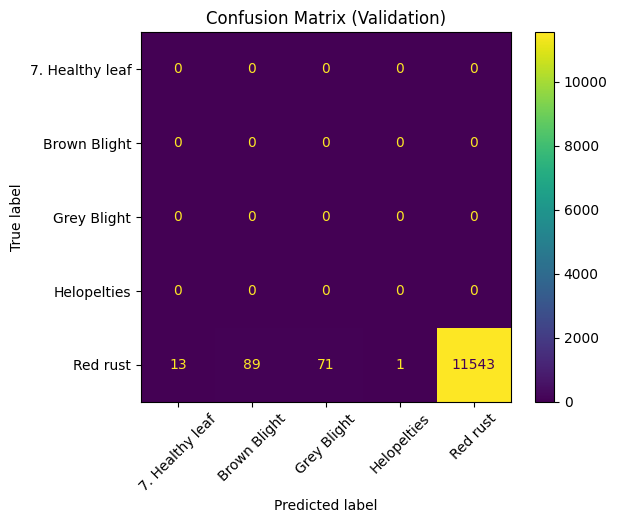

In [18]:
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from collections import Counter
import matplotlib.pyplot as plt
import numpy as np

y_true, y_pred = [], []

for x, y in val_ds:
    p = model.predict(x, verbose=0)
    y_true.extend(np.argmax(y.numpy(), axis=1))
    y_pred.extend(np.argmax(p, axis=1))

print("✅ True distribution:", {class_names[k]: v for k, v in Counter(y_true).items()})
print("✅ Pred distribution:", {class_names[k]: v for k, v in Counter(y_pred).items()})

print("\n✅ Classification Report:\n")
print(classification_report(y_true, y_pred, target_names=class_names, digits=4))

cm = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)

plt.figure(figsize=(8,8))
disp.plot(values_format="d", xticks_rotation=45)
plt.title("Confusion Matrix (Validation)")
plt.show()

In [19]:
remedy = {
    "7. Healthy leaf": "Healthy: maintain field hygiene and regular monitoring.",
    "Brown Blight": "Brown blight: remove infected leaves, improve airflow, avoid overhead watering; fungicide if severe.",
    "Grey Blight": "Grey blight: prune infected parts, reduce humidity, ensure spacing; fungicide if needed.",
    "Red Rust": "Red rust (algal leaf spot): reduce shading, increase sunlight; copper spray if necessary.",
    "Helopelties": "Helopeltis (tea mosquito bug): IPM—monitoring, pruning; neem/approved control if infestation increases."
}

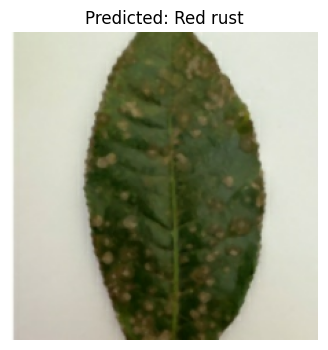

Predicted: Red rust
Remedy: Consult an agriculture expert.


In [20]:
import numpy as np
import matplotlib.pyplot as plt

images, labels = next(iter(val_ds))
img = images[0]

pred = model.predict(np.expand_dims(img.numpy(), axis=0), verbose=0)
pred_label = int(np.argmax(pred[0]))
pred_class = class_names[pred_label]

plt.figure(figsize=(4,4))
plt.imshow(img.numpy().astype("uint8"))
plt.axis("off")
plt.title(f"Predicted: {pred_class}")
plt.show()

print("Predicted:", pred_class)
print("Remedy:", remedy.get(pred_class, "Consult an agriculture expert."))

In [21]:
model.save("tea_leaf_model_final.keras")
!cp tea_leaf_model_final.keras /content/drive/MyDrive/
print("✅ Saved to Drive: tea_leaf_model_final.keras")

✅ Saved to Drive: tea_leaf_model_final.keras


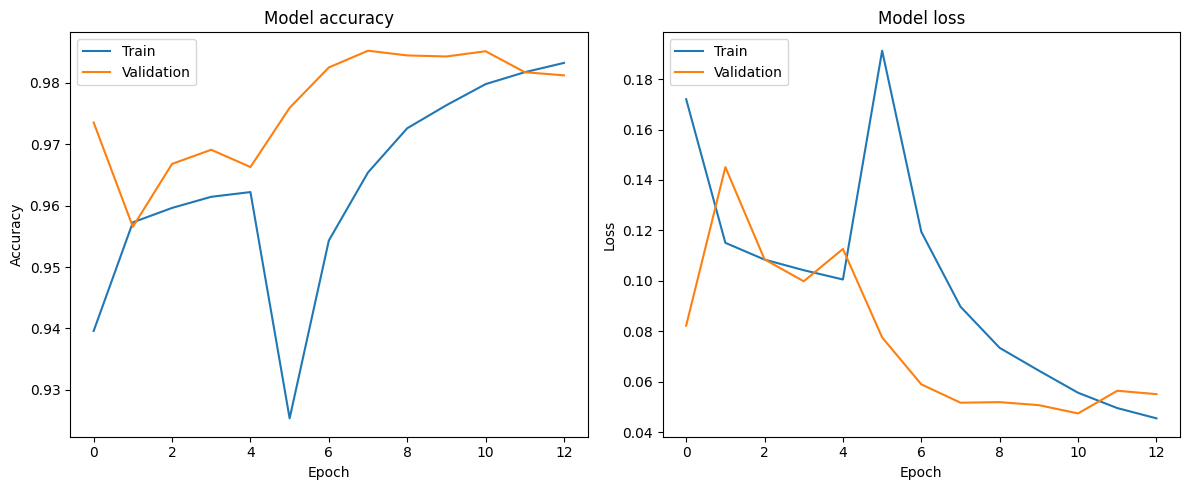

In [22]:
import matplotlib.pyplot as plt

# Combine history for initial training and fine-tuning
combined_history = {
    'accuracy': history.history['accuracy'] + history_ft.history['accuracy'],
    'val_accuracy': history.history['val_accuracy'] + history_ft.history['val_accuracy'],
    'loss': history.history['loss'] + history_ft.history['loss'],
    'val_loss': history.history['val_loss'] + history_ft.history['val_loss']
}

plt.figure(figsize=(12, 5))

# Plot training & validation accuracy values
plt.subplot(1, 2, 1)
plt.plot(combined_history['accuracy'])
plt.plot(combined_history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(combined_history['loss'])
plt.plot(combined_history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

The plots above show the accuracy and loss curves during the training process, including both the initial training and the fine-tuning steps. You can observe how the model performed on both the training and validation datasets over the epochs.